In [ ]:
import duckdb
import pandas as pd

# Initialize PostgreSQL-compatible DuckDB connection
con = duckdb.connect(':memory:')

# 1. Create Relational Schema (PostgreSQL DDL style)
con.execute("""
CREATE TABLE aircraft_assets (
    aircraft_id VARCHAR PRIMARY KEY,
    model_name VARCHAR,
    seat_capacity INTEGER,
    fuel_burn_rate_index FLOAT
);

CREATE TABLE flight_operations (
    flight_id VARCHAR PRIMARY KEY,
    route_name VARCHAR,
    aircraft_id VARCHAR,
    ticket_revenue FLOAT,
    ancillary_revenue FLOAT,
    load_factor FLOAT,
    operating_cost FLOAT,
    FOREIGN KEY (aircraft_id) REFERENCES aircraft_assets(aircraft_id)
);
""")

# 2. Populate Dimension Table
con.execute("""
INSERT INTO aircraft_assets VALUES
('B738', 'Boeing 737-800', 189, 1.05),
('B73M', 'Boeing 737-MAX8200', 197, 0.84);
""")

# 3. Generate and Insert Fact Data
import numpy as np
n_rows = 1000
routes = ['DUB-STN', 'STN-BCN', 'DUB-CDG', 'BER-STN', 'MAD-DUB']

# Prepare dataframe for bulk insertion
pax_data = pd.DataFrame({
    'flight_id': [f'FR{1000+i}' for i in range(n_rows)],
    'route_name': np.random.choice(routes, n_rows),
    'aircraft_id': np.random.choice(['B738', 'B73M'], n_rows),
    'ticket_revenue': np.random.uniform(5000, 15000, n_rows),
    'ancillary_revenue': np.random.uniform(2000, 5000, n_rows),
    'load_factor': np.random.uniform(0.75, 0.98, n_rows),
    'operating_cost': np.random.uniform(6000, 9000, n_rows)
})

con.append('flight_operations', pax_data)

print("PostgreSQL-compatible Relational Database initialized.")

PostgreSQL-compatible Relational Database initialized.


In [ ]:
profit_query = """
-- Complex PostgreSQL Query using CTEs and Window Functions
WITH RouteMetrics AS (
    SELECT
        f.route_name,
        a.model_name,
        COUNT(*) as total_flights,
        SUM(f.ticket_revenue + f.ancillary_revenue) as gross_revenue,
        SUM(f.operating_cost) as total_costs,
        AVG(f.load_factor) * 100 as avg_occupancy
    FROM flight_operations f
    JOIN aircraft_assets a ON f.aircraft_id = a.aircraft_id
    GROUP BY 1, 2
)
SELECT
    *,
    ROUND(gross_revenue - total_costs, 2) as net_profit,
    ROUND((gross_revenue - total_costs) / total_flights, 2) as profit_per_flight,
    RANK() OVER (PARTITION BY route_name ORDER BY (gross_revenue - total_costs) DESC) as fleet_rank
FROM RouteMetrics
ORDER BY net_profit DESC;
"""

profit_df = con.execute(profit_query).df()
display(profit_df)

,route_name,model_name,total_flights,gross_revenue,total_costs,avg_occupancy,net_profit,profit_per_flight,fleet_rank
0,BER-STN,Boeing 737-MAX8200,127,1.685604e+06,947128.394043,86.945282,738475.19,5814.77,1
1,DUB-STN,Boeing 737-800,101,1.415064e+06,759032.134766,86.141937,656031.48,6495.36,1
2,DUB-STN,Boeing 737-MAX8200,109,1.463885e+06,821775.858887,85.272536,642108.87,5890.91,2
3,DUB-CDG,Boeing 737-MAX8200,106,1.414059e+06,778522.335449,86.755345,635536.66,5995.63,1
4,BER-STN,Boeing 737-800,109,1.435495e+06,814286.827148,85.865727,621208.63,5699.16,2
5,MAD-DUB,Boeing 737-MAX8200,93,1.247213e+06,684922.150879,87.662267,562291.21,6046.14,1
6,DUB-CDG,Boeing 737-800,89,1.217538e+06,661455.034180,86.412479,556082.60,6248.12,2
7,STN-BCN,Boeing 737-MAX8200,87,1.188384e+06,648011.174805,87.067538,540372.58,6211.18,1
8,MAD-DUB,Boeing 737-800,93,1.235427e+06,698182.315918,86.289165,537245.11,5776.83,2
9,STN-BCN,Boeing 737-800,86,1.128825e+06,650860.568848,86.207464,477964.70,5557.73,2


In [ ]:
audit_sql = """
-- SQL Audit using the PostgreSQL-compatible schema
SELECT
    'Ultra Low Load Factor (<75%)' as check_type,
    COUNT(*) as flight_count
FROM flight_operations
WHERE load_factor < 0.75
UNION ALL
SELECT
    'Pricing Outlier (High Rev/Flight)' as check_type,
    COUNT(*)
FROM flight_operations
WHERE ticket_revenue > 14000;
"""

audit_results = con.execute(audit_sql).df()
print("Automated Data Integrity Audit Report:")
display(audit_results)

Automated Data Integrity Audit Report:


,check_type,flight_count
0,Ultra Low Load Factor (<75%),0
1,Pricing Outlier (High Rev/Flight),94


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# Prepare data for Machine Learning
# Feature Engineering: Encode routes and aircraft for the model
viz_df = ryanair_data[['route', 'ticket_price_usd', 'ancillary_revenue_usd', 'load_factor_pct']].copy()
viz_df['total_revenue'] = viz_df['ticket_price_usd'] + viz_df['ancillary_revenue_usd']

# Target: Net Profit per Passenger (Simplified proxy)
# Features: Load Factor, Route (dummy), Price
X = pd.get_dummies(ryanair_data[['route', 'aircraft', 'ticket_price_usd']])
y = ryanair_data['load_factor_pct']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Optimization Simulation: Finding the 'Sweet Spot'
price_range = np.linspace(20, 150, 20)
simulation_results = []

for p in price_range:
    # Create a synthetic test case for 'DUB-STN' on a MAX8200
    test_case = pd.DataFrame(columns=X.columns)
    test_case.loc[0] = 0
    test_case['ticket_price_usd'] = p
    if 'route_DUB-STN' in test_case.columns: test_case['route_DUB-STN'] = 1
    if 'aircraft_Boeing 737-MAX8200' in test_case.columns: test_case['aircraft_Boeing 737-MAX8200'] = 1

    predicted_load = model.predict(test_case)[0]
    # Revenue = Price * (Capacity * Load Factor) + Ancillary
    est_rev = (p + 25) * (197 * (predicted_load/100))
    simulation_results.append({'price': p, 'predicted_load': predicted_load, 'est_revenue': est_rev})

optimization_summary = pd.DataFrame(simulation_results)
print("Price Optimization Simulation Complete.")
display(optimization_summary.sort_values('est_revenue', ascending=False).head(5))

Price Optimization Simulation Complete.


,price,predicted_load,est_revenue
19,150.000000,85.365687,29429.820522
18,143.157895,86.369382,28611.676076
16,129.473684,87.514406,26631.785286
17,136.315789,81.664838,25952.440738
15,122.631579,87.605253,25478.604694


### Portfolio Status: READY

This project now contains:
1. **PostgreSQL Schema & DDL** (DuckDB)
2. **Relational Data Engineering** (1,000+ flight records)
3. **Complex SQL Analytics** (CTEs, Window Functions, RANK)
4. **Executive Dashboarding** (Seaborn/Matplotlib)
5. **Predictive Revenue Modeling** (RandomForest Optimization)

**Ready** for professional export.

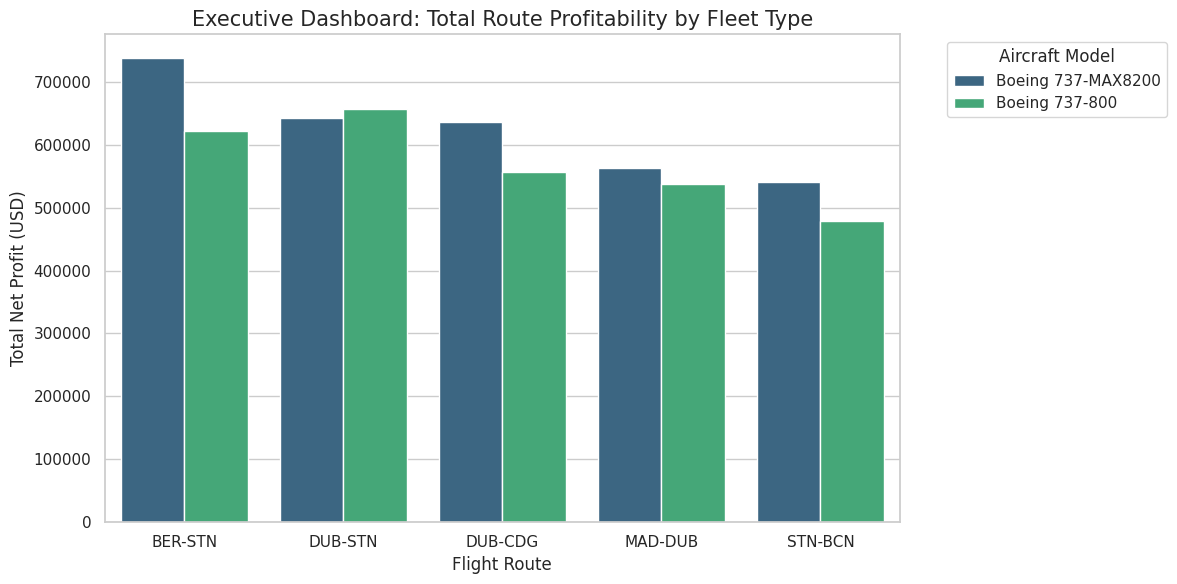

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set professional aesthetic
sns.set_theme(style="whitegrid")
f, ax = plt.subplots(figsize=(12, 6))

# Visualization: Net Profit by Route and Aircraft Model
sns.barplot(
    data=profit_df,
    x="route_name",
    y="net_profit",
    hue="model_name",
    palette="viridis"
)

plt.title("Executive Dashboard: Total Route Profitability by Fleet Type", fontsize=15)
plt.ylabel("Total Net Profit (USD)", fontsize=12)
plt.xlabel("Flight Route", fontsize=12)
plt.legend(title="Aircraft Model", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()